Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats


Load Dataset

In [5]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 4000 rows x 28 columns


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3





Before cleaning or analyzing the data, we first understand its structure, data types, and quality.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [7]:
# Numeric summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [8]:
# Categorical summary
df.describe(include='object').T

C:\Users\neera\AppData\Local\Temp\ipykernel_20404\1311145587.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T


,count,unique,top,freq
Farm_ID,4000,4000,SF10001,1
State,4000,8,Andhra Pradesh,529
District,4000,10,Ludhiana,427
Crop,4000,8,Rice,690
Season,4000,3,Kharif,1779
Irrigation_Method,4000,4,Flood,1310


In [9]:
# Check missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing_Count': missing, 'Missing_Pct': missing_pct})

,Missing_Count,Missing_Pct
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [10]:
# Check duplicates
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate Farm_ID values:", df['Farm_ID'].duplicated().sum())

Fully duplicated rows: 0
Duplicate Farm_ID values: 0


In [11]:
# Check unique values
for col in ['Season', 'Crop', 'State', 'Irrigation_Method']:
    print(f"\n{col} — {df[col].nunique()} unique values:")
    print(df[col].value_counts())


Season — 3 unique values:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Crop — 8 unique values:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

State — 8 unique values:
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

Irrigation_Method — 4 unique values:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


In [ ]:
df_clean = df.copy()

cols_to_impute = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

for col in cols_to_impute:
    df_clean[col] = df_clean.groupby(['Season', 'Crop'])[col].transform(
        lambda x: x.fillna(x.median())
    )
    
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Remaining missing values after imputation:")
print(df_clean.isnull().sum().sum())

Remaining missing values after imputation:
0


In [12]:
# Check for possible outliers using the IQR rule
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

numeric_cols = ['Yield_Tonnes_Ha', 'Profit_INR', 'Rainfall_mm', 'Water_Used_m3', 'Fertilizer_kg_ha']
for c in numeric_cols:
    print(f"{c}: {iqr_outlier_count(df_clean[c])} potential outliers (IQR method)")

Yield_Tonnes_Ha: 304 potential outliers (IQR method)
Profit_INR: 404 potential outliers (IQR method)
Rainfall_mm: 0 potential outliers (IQR method)
Water_Used_m3: 276 potential outliers (IQR method)
Fertilizer_kg_ha: 15 potential outliers (IQR method)


In [13]:
# Create a few columns that will help with the comparison
df_clean['Profit_Margin_pct'] = (df_clean['Profit_INR'] / df_clean['Revenue_INR'].replace(0, np.nan)) * 100
df_clean['Cost_per_Hectare'] = df_clean['Total_Cost_INR'] / df_clean['Farm_Area_Hectares']
df_clean['Revenue_per_Hectare'] = df_clean['Revenue_INR'] / df_clean['Farm_Area_Hectares']

# Keep the seasons in the same order in the charts
season_order = ['Kharif', 'Rabi', 'Zaid']
df_clean['Season'] = pd.Categorical(df_clean['Season'], categories=season_order, ordered=True)

df_clean.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_pct,Cost_per_Hectare,Revenue_per_Hectare
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,23700,42662,30810,-11852,237,5.485,55.3,-38.468030,80494.339623,58132.075472
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,20613,492351,40401,-451950,4953,0.396,49.9,-1118.660429,75398.315467,6186.983155
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,75283,315210,190466,-124744,1275,1.984,33.7,-65.494104,64858.024691,39190.534979
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,24244,296444,200740,-95704,3834,2.160,50.6,-47.675600,65876.444444,44608.888889
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,20818,337959,193607,-144352,3287,2.829,32.3,-74.559288,80275.296912,45987.410926


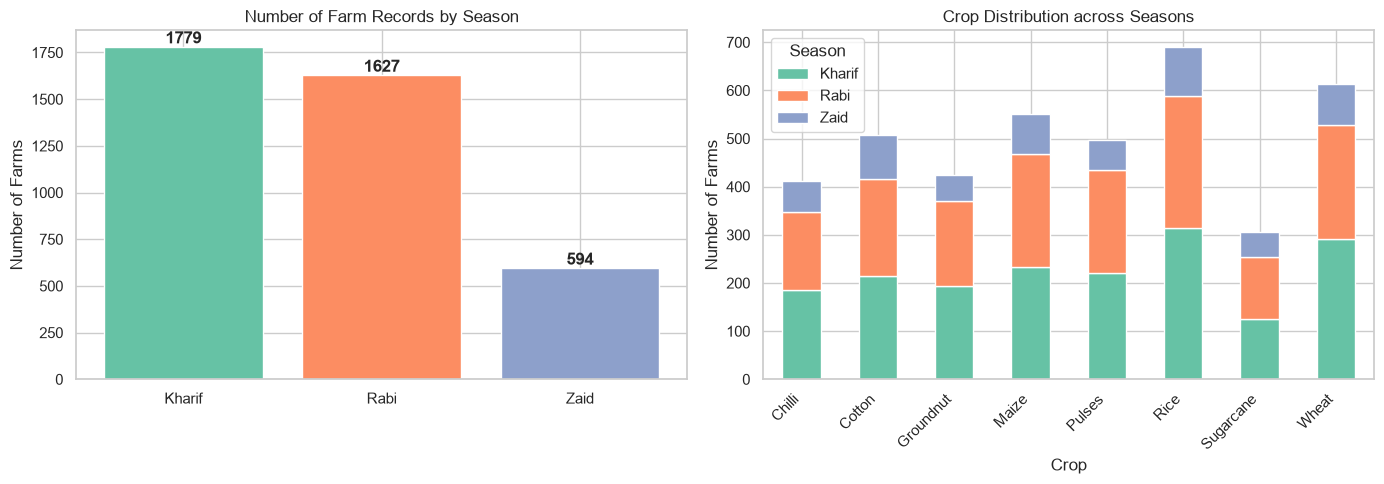

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

season_counts = df_clean['Season'].value_counts().reindex(season_order)
axes[0].bar(season_counts.index, season_counts.values, color=sns.color_palette("Set2", 3))
axes[0].set_title("Number of Farm Records by Season")
axes[0].set_ylabel("Number of Farms")
for i, v in enumerate(season_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

crop_season = pd.crosstab(df_clean['Crop'], df_clean['Season'])
crop_season.plot(kind='bar', stacked=True, ax=axes[1], color=sns.color_palette("Set2", 3))
axes[1].set_title("Crop Distribution across Seasons")
axes[1].set_ylabel("Number of Farms")
axes[1].legend(title="Season")
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig("chart_01_season_crop_distribution.png", bbox_inches='tight')
plt.show()



Seasons are fundamentally defined by weather. We compare rainfall, temperature, humidity and
sunlight across the three seasons.

C:\Users\neera\AppData\Local\Temp\ipykernel_22768\2036971421.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y=col, order=season_order, ax=ax, palette="Set2")
C:\Users\neera\AppData\Local\Temp\ipykernel_22768\2036971421.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y=col, order=season_order, ax=ax, palette="Set2")
C:\Users\neera\AppData\Local\Temp\ipykernel_22768\2036971421.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y=col, order=season_order, 

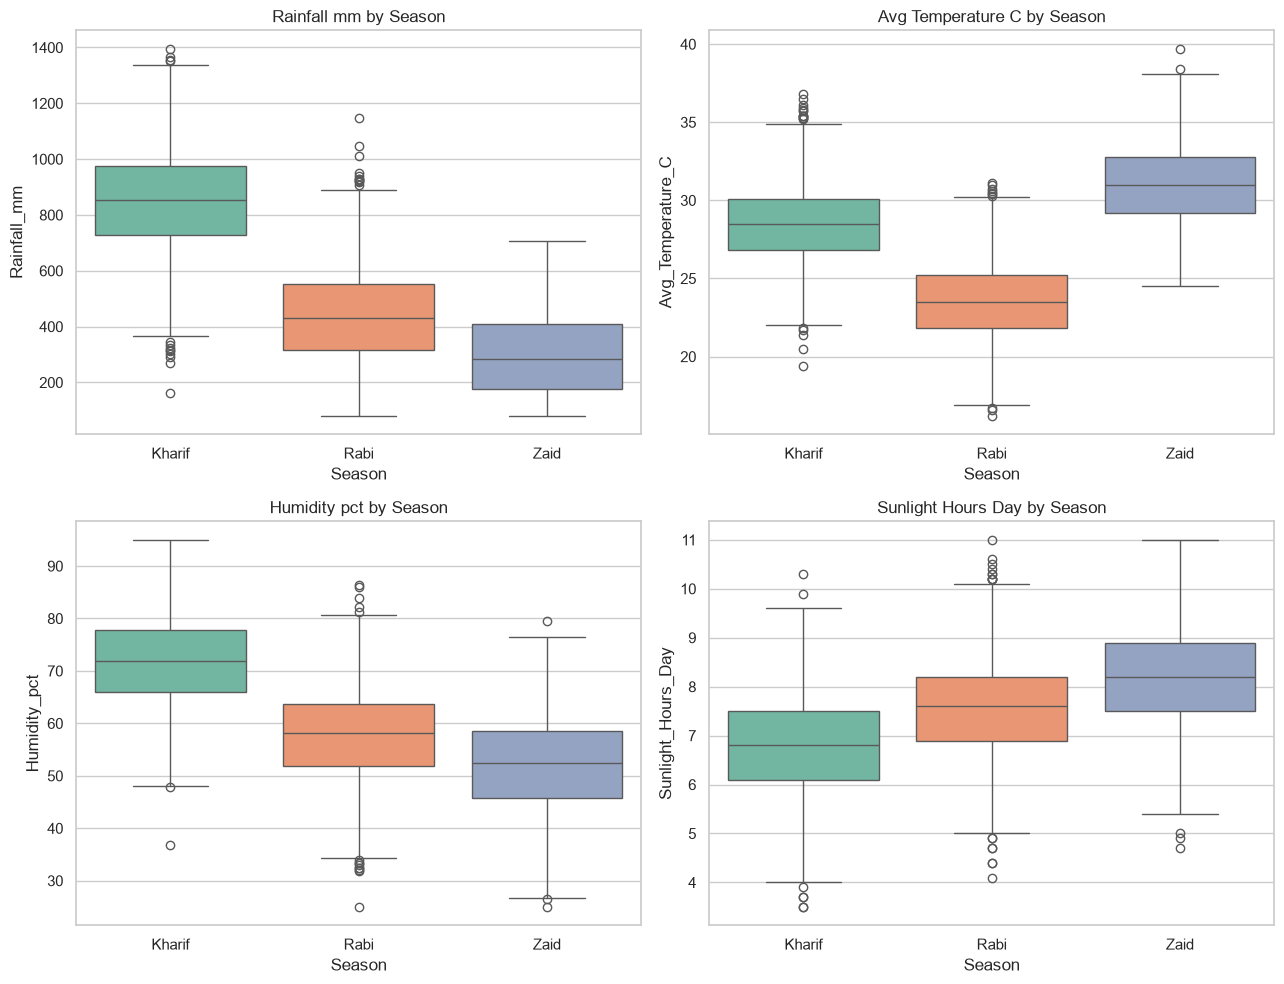

In [15]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day']

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()
for ax, col in zip(axes, env_cols):
    sns.boxplot(data=df_clean, x='Season', y=col, order=season_order, ax=ax, palette="Set2")
    ax.set_title(f"{col.replace('_', ' ')} by Season")
plt.tight_layout()
plt.savefig("chart_02_environment_by_season.png", bbox_inches='tight')
plt.show()

In [16]:
env_summary = df_clean.groupby('Season', observed=True)[env_cols].mean().round(2)
env_summary

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day
Season,,,,
Kharif,852.10,28.45,71.81,6.79
Rabi,435.95,23.49,57.89,7.59
Zaid,299.16,31.04,52.01,8.18




This is central to the problem statement — how does agricultural performance (yield, production)
vary across seasons?

C:\Users\neera\AppData\Local\Temp\ipykernel_22768\2324414020.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y='Yield_Tonnes_Ha', order=season_order, ax=axes[0], palette="Set2")
C:\Users\neera\AppData\Local\Temp\ipykernel_22768\2324414020.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y='Production_Tonnes', order=season_order,


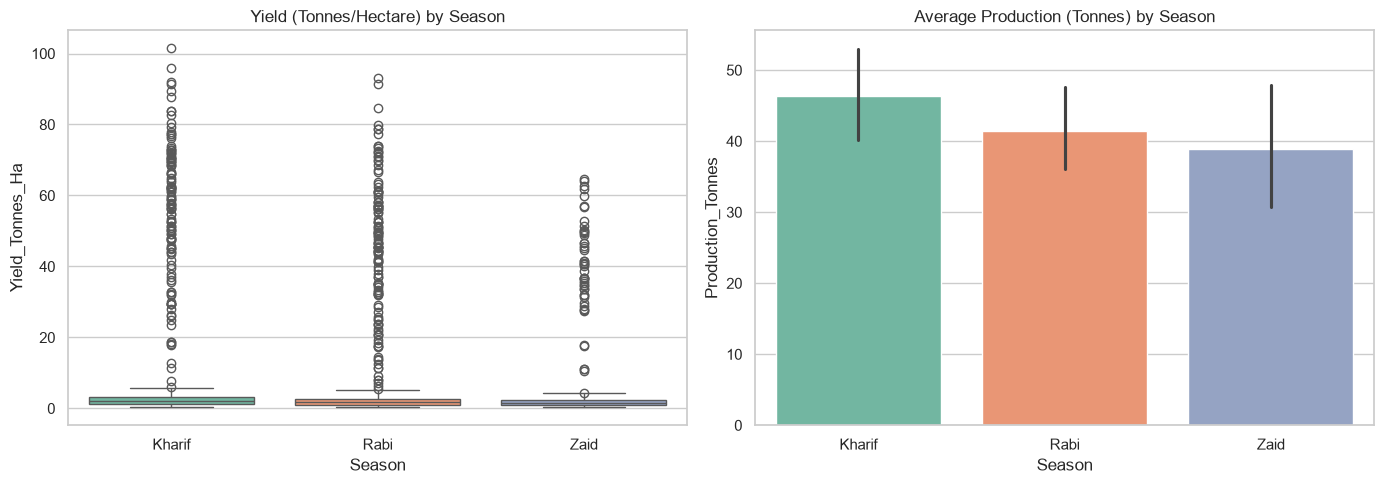

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_clean, x='Season', y='Yield_Tonnes_Ha', order=season_order, ax=axes[0], palette="Set2")
axes[0].set_title("Yield (Tonnes/Hectare) by Season")

sns.barplot(data=df_clean, x='Season', y='Production_Tonnes', order=season_order,
            estimator=np.mean, ax=axes[1], palette="Set2", errorbar=('ci', 95))
axes[1].set_title("Average Production (Tonnes) by Season")

plt.tight_layout()
plt.savefig("chart_03_yield_production_by_season.png", bbox_inches='tight')
plt.show()

In [18]:
yield_summary = df_clean.groupby('Season', observed=True)['Yield_Tonnes_Ha'].agg(
    ['mean', 'median', 'std', 'min', 'max']).round(2)
yield_summary

,mean,median,std,min,max
Season,,,,,
Kharif,5.63,1.95,14.39,0.3,101.44
Rabi,5.09,1.66,12.83,0.3,93.13
Zaid,4.64,1.45,11.27,0.3,64.76


In [20]:
econ_cols = ['Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Profit_Margin_pct']
econ_summary = df_clean.groupby('Season', observed=True)[econ_cols].mean().round(0)
econ_summary

,Total_Cost_INR,Revenue_INR,Profit_INR,Profit_Margin_pct
Season,,,,
Kharif,531804.0,710719.0,178915.0,-39.0
Rabi,513837.0,601526.0,87689.0,-44.0
Zaid,543977.0,519172.0,-24805.0,-69.0


C:\Users\neera\AppData\Local\Temp\ipykernel_22768\2529337146.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y='Profit_INR', order=season_order, ax=axes[1], palette="Set2")


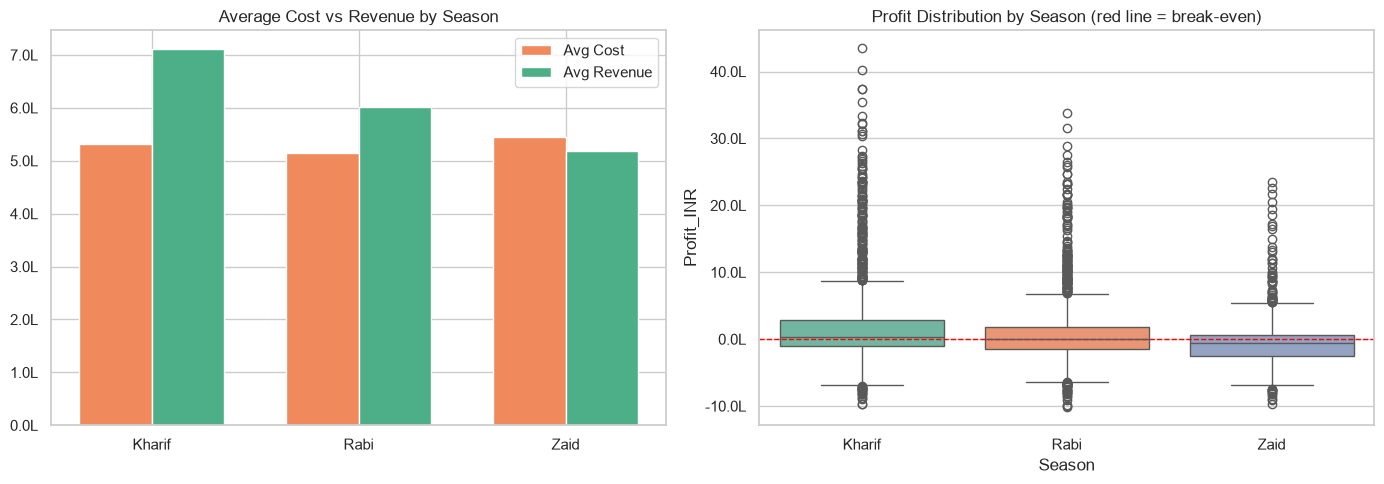

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(season_order))
width = 0.35
cost_means = df_clean.groupby('Season', observed=True)['Total_Cost_INR'].mean().reindex(season_order)
rev_means = df_clean.groupby('Season', observed=True)['Revenue_INR'].mean().reindex(season_order)

axes[0].bar(x - width/2, cost_means, width, label='Avg Cost', color='#F08A5D')
axes[0].bar(x + width/2, rev_means, width, label='Avg Revenue', color='#4CAF87')
axes[0].set_xticks(x)
axes[0].set_xticklabels(season_order)
axes[0].set_title("Average Cost vs Revenue by Season")
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e5:.1f}L'))

sns.boxplot(data=df_clean, x='Season', y='Profit_INR', order=season_order, ax=axes[1], palette="Set2")
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title("Profit Distribution by Season (red line = break-even)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e5:.1f}L'))

plt.tight_layout()
plt.savefig("chart_04_economics_by_season.png", bbox_inches='tight')
plt.show()

In [22]:
loss_pct = df_clean.groupby('Season', observed=True)['Profit_INR'].apply(lambda s: (s < 0).mean() * 100).round(1)
print("Percentage of loss-making farms by season:")
print(loss_pct)

Percentage of loss-making farms by season:
Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
Name: Profit_INR, dtype: float64




Examining differences in resource usage — water, fertilizer, pesticide — across seasons.

In [23]:
resource_cols = ['Water_Used_m3', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Efficiency_t_per_1000m3']
resource_summary = df_clean.groupby('Season', observed=True)[resource_cols].mean().round(2)
resource_summary

,Water_Used_m3,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,6102.20,187.08,5.08,5.89
Rabi,5846.99,185.41,5.02,5.19
Zaid,6419.89,184.64,5.17,4.41


C:\Users\neera\AppData\Local\Temp\ipykernel_22768\1066680806.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y=col, order=season_order, ax=ax, palette="Set2",
C:\Users\neera\AppData\Local\Temp\ipykernel_22768\1066680806.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y=col, order=season_order, ax=ax, palette="Set2",
C:\Users\neera\AppData\Local\Temp\ipykernel_22768\1066680806.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y=col, order=season_order, 

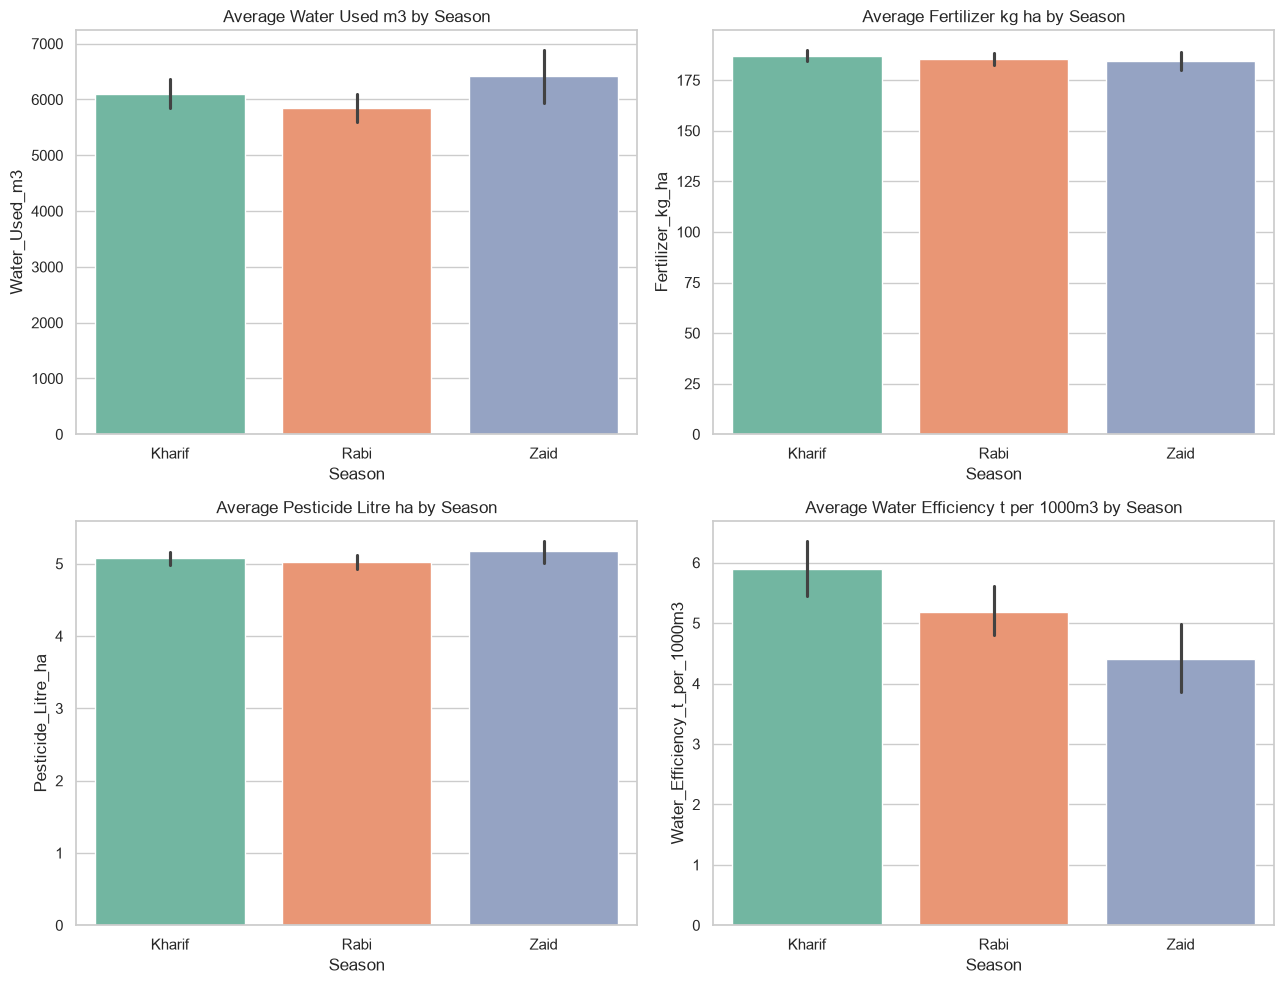

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()
for ax, col in zip(axes, resource_cols):
    sns.barplot(data=df_clean, x='Season', y=col, order=season_order, ax=ax, palette="Set2",
                estimator=np.mean, errorbar=('ci', 95))
    ax.set_title(f"Average {col.replace('_', ' ')} by Season")
plt.tight_layout()
plt.savefig("chart_05_resources_by_season.png", bbox_inches='tight')
plt.show()

Irrigation Method Preference by Season

In [25]:
irrig_season = pd.crosstab(df_clean['Season'], df_clean['Irrigation_Method'], normalize='index') * 100
irrig_season = irrig_season.round(1)
irrig_season

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.8,33.2,26.0,18.0
Rabi,22.7,32.3,26.9,18.0
Zaid,23.6,32.7,23.6,20.2


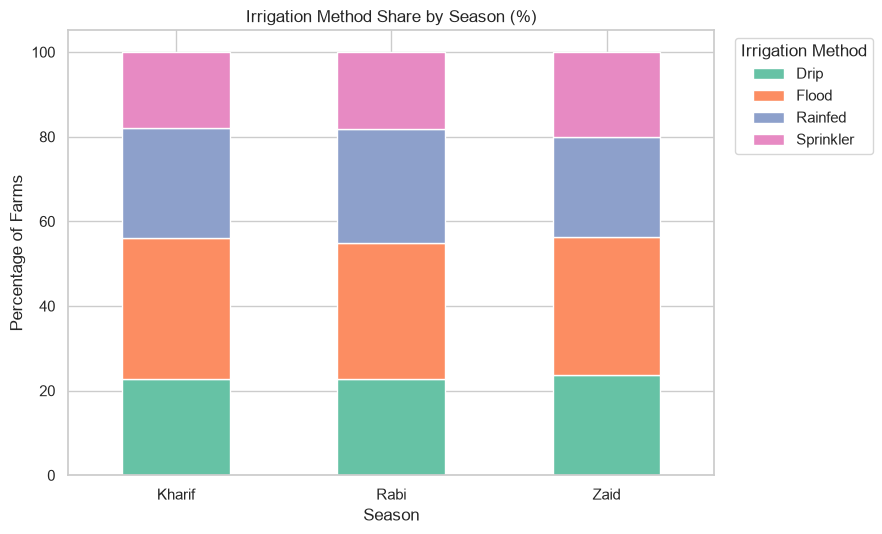

In [26]:
irrig_season.plot(kind='bar', stacked=True, figsize=(9, 5.5), color=sns.color_palette("Set2", 4))
plt.title("Irrigation Method Share by Season (%)")
plt.ylabel("Percentage of Farms")
plt.xticks(rotation=0)
plt.legend(title="Irrigation Method", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig("chart_06_irrigation_by_season.png", bbox_inches='tight')
plt.show()

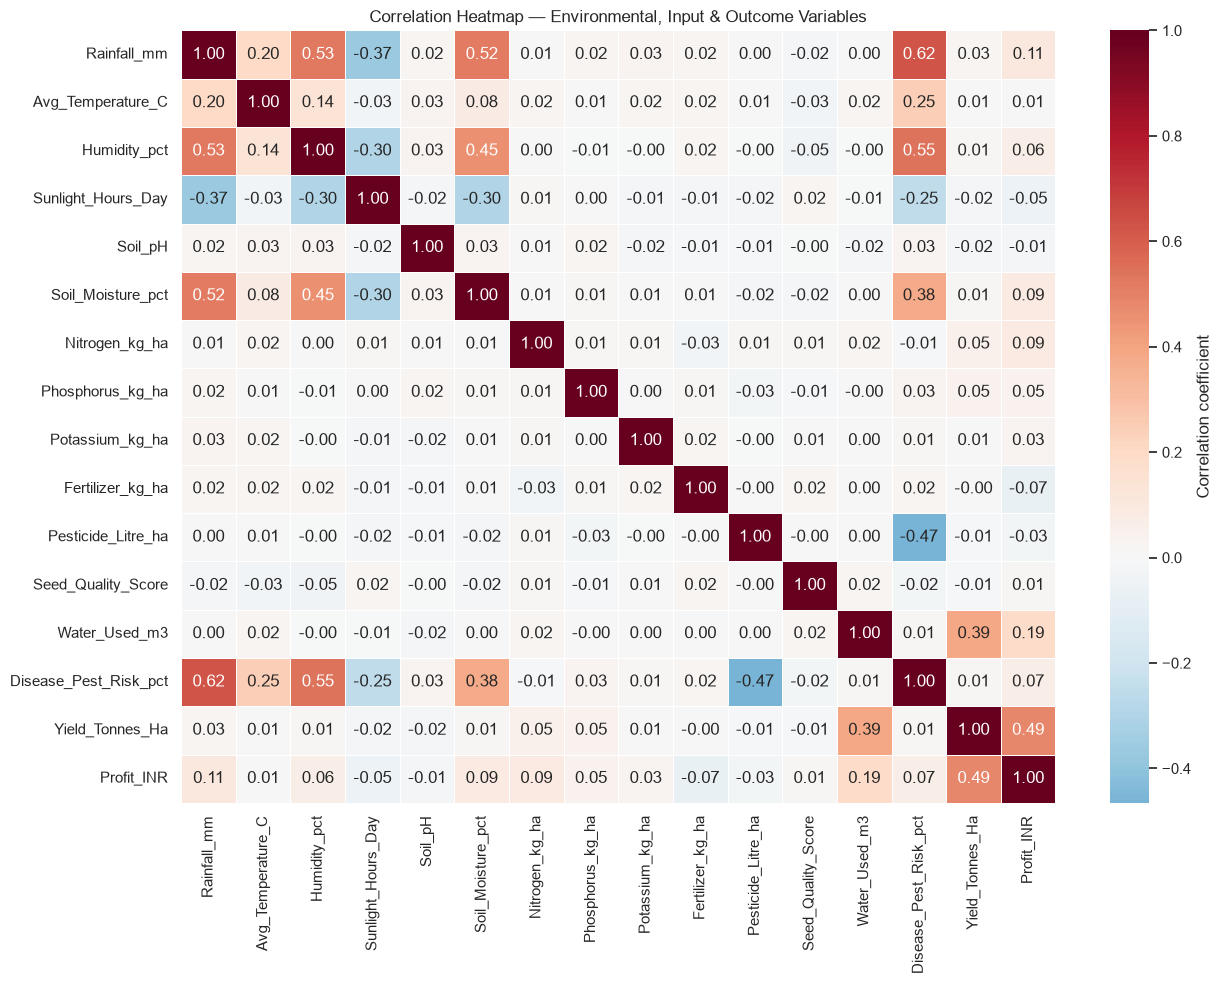

In [27]:
corr_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH',
             'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha',
             'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Water_Used_m3',
             'Disease_Pest_Risk_pct', 'Yield_Tonnes_Ha', 'Profit_INR']

corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, cbar_kws={'label': 'Correlation coefficient'})
plt.title("Correlation Heatmap — Environmental, Input & Outcome Variables")
plt.tight_layout()
plt.savefig("chart_07_correlation_heatmap.png", bbox_inches='tight')
plt.show()

In [28]:
# Check which variables are most related to yield and profit
yield_corr = corr_matrix['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').sort_values(key=abs, ascending=False)
profit_corr = corr_matrix['Profit_INR'].drop('Profit_INR').sort_values(key=abs, ascending=False)

print("Strongest correlations with Yield:")
print(yield_corr.head(6))
print("\nStrongest correlations with Profit:")
print(profit_corr.head(6))

Strongest correlations with Yield:
Profit_INR          0.489350
Water_Used_m3       0.387373
Nitrogen_kg_ha      0.053633
Phosphorus_kg_ha    0.046685
Rainfall_mm         0.026858
Soil_pH            -0.021767
Name: Yield_Tonnes_Ha, dtype: float64

Strongest correlations with Profit:
Yield_Tonnes_Ha      0.489350
Water_Used_m3        0.190278
Rainfall_mm          0.105972
Soil_Moisture_pct    0.092204
Nitrogen_kg_ha       0.085016
Fertilizer_kg_ha    -0.073542
Name: Profit_INR, dtype: float64


In [ ]:
pivot_crop = df_clean.pivot_table(values='Yield_Tonnes_Ha', index='Crop', columns='Season', aggfunc='mean', observed=True).round(2)
pivot_crop

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.62,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.96,38.42
Wheat,2.26,2.06,1.75


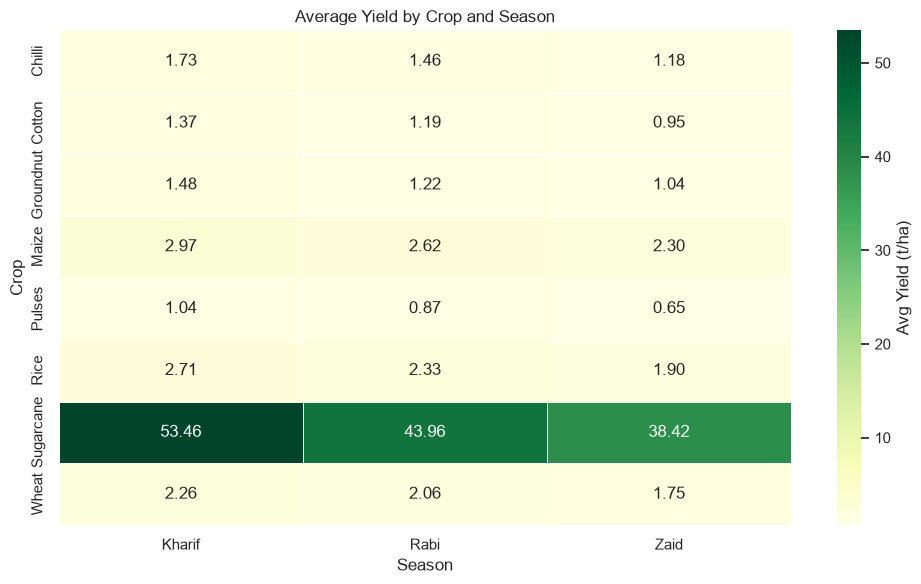

In [30]:
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_crop, annot=True, fmt='.2f', cmap='YlGn', linewidths=0.5,
            cbar_kws={'label': 'Avg Yield (t/ha)'})
plt.title("Average Yield by Crop and Season")
plt.tight_layout()
plt.savefig("chart_08_crop_season_yield_heatmap.png", bbox_inches='tight')
plt.show()

In [14]:
pivot_state = df_clean.pivot_table(values='Profit_INR', index='State', columns='Season', aggfunc='mean', observed=True).round(0)
pivot_state

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169316.0,26316.0,-84085.0
Gujarat,217051.0,82846.0,-106930.0
Karnataka,201226.0,70953.0,23311.0
Madhya Pradesh,134242.0,61576.0,210.0
Maharashtra,168801.0,159582.0,-40598.0
Punjab,133779.0,169295.0,62110.0
Tamil Nadu,211304.0,70457.0,-15175.0
Telangana,199668.0,62825.0,-34621.0


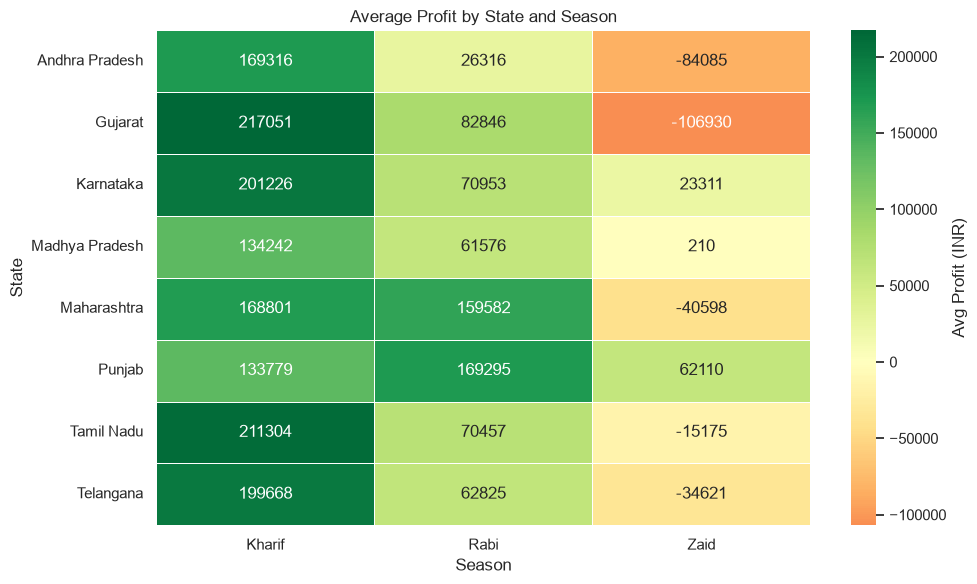

In [32]:
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_state, annot=True, fmt='.0f', cmap='RdYlGn', center=0, linewidths=0.5,
            cbar_kws={'label': 'Avg Profit (INR)'})
plt.title("Average Profit by State and Season")
plt.tight_layout()
plt.savefig("chart_09_state_season_profit_heatmap.png", bbox_inches='tight')
plt.show()

Disease & Pest Risk Across Seasons

C:\Users\neera\AppData\Local\Temp\ipykernel_22768\2384204685.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='Season', y='Disease_Pest_Risk_pct', order=season_order,


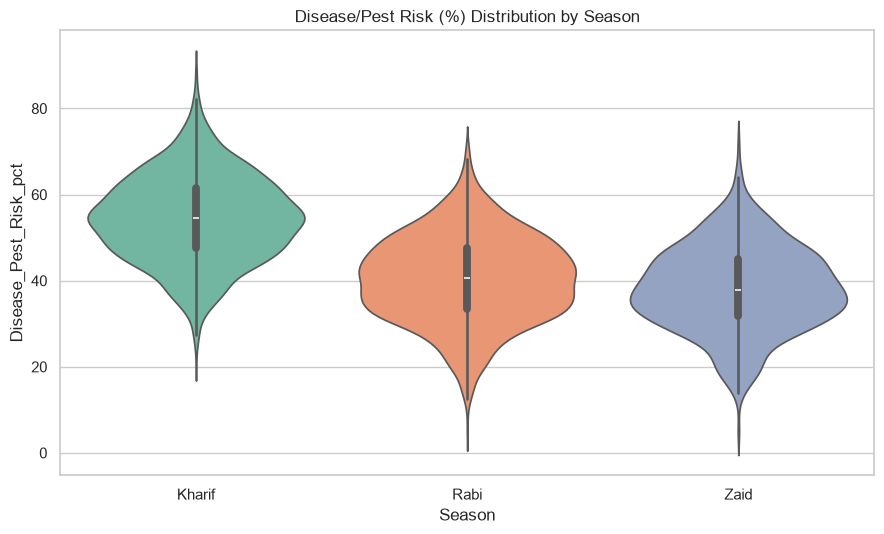

In [33]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.violinplot(data=df_clean, x='Season', y='Disease_Pest_Risk_pct', order=season_order,
               palette="Set2", ax=ax)
ax.set_title("Disease/Pest Risk (%) Distribution by Season")
plt.tight_layout()
plt.savefig("chart_10_disease_risk_by_season.png", bbox_inches='tight')
plt.show()

In [34]:
risk_summary = df_clean.groupby('Season', observed=True)['Disease_Pest_Risk_pct'].mean().round(2)
risk_summary

Season
Kharif    54.47
Rabi      40.48
Zaid      38.22
Name: Disease_Pest_Risk_pct, dtype: float64